In [1]:
pip install pandas numpy matplotlib seaborn jupyter



   ---------- ----------------------------- 1/4 [uri-template]
   ------------------------------ --------- 3/4 [isoduration]
   ---------------------------------------- 4/4 [isoduration]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv("data/walmart_cleaned.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/walmart_cleaned.csv'

In [3]:
import os

print(os.getcwd())

C:\Users\USER\Desktop\Sales-Forecasting-System\notebooks


In [4]:
os.listdir()

['.ipynb_checkpoints', 'sales_analysis.ipynb']

In [5]:
df = pd.read_csv("../data/walmart_cleaned.csv")

In [6]:
df.shape()

TypeError: 'tuple' object is not callable

In [7]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    421570 non-null  int64  
 1   Store         421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   IsHoliday     421570 non-null  int64  
 4   Dept          421570 non-null  float64
 5   Weekly_Sales  421570 non-null  float64
 6   Temperature   421570 non-null  float64
 7   Fuel_Price    421570 non-null  float64
 8   MarkDown1     421570 non-null  float64
 9   MarkDown2     421570 non-null  float64
 10  MarkDown3     421570 non-null  float64
 11  MarkDown4     421570 non-null  float64
 12  MarkDown5     421570 non-null  float64
 13  CPI           421570 non-null  float64
 14  Unemployment  421570 non-null  float64
 15  Type          421570 non-null  int64  
 16  Size          421570 non-null  int64  
dtypes: float64(11), int64(5), object(1)
memory usage

Unnamed: 0      0
Store           0
Date            0
IsHoliday       0
Dept            0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df['Date'].dtype

dtype('<M8[ns]')

In [10]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [11]:
df.head()

,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,2010-02-05,0,1.0,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
1,1,2010-02-05,0,26.0,11737.12,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
2,1,2010-02-05,0,17.0,13223.76,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
3,1,2010-02-05,0,45.0,37.44,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
4,1,2010-02-05,0,28.0,1085.29,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315


In [12]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Week'] = df['Date'].dt.isocalendar().week

In [13]:
df.head()

,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Quarter,Week
0,1,2010-02-05,0,1.0,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,2010,2,1,5
1,1,2010-02-05,0,26.0,11737.12,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,2010,2,1,5
2,1,2010-02-05,0,17.0,13223.76,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,2010,2,1,5
3,1,2010-02-05,0,45.0,37.44,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,2010,2,1,5
4,1,2010-02-05,0,28.0,1085.29,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315,2010,2,1,5


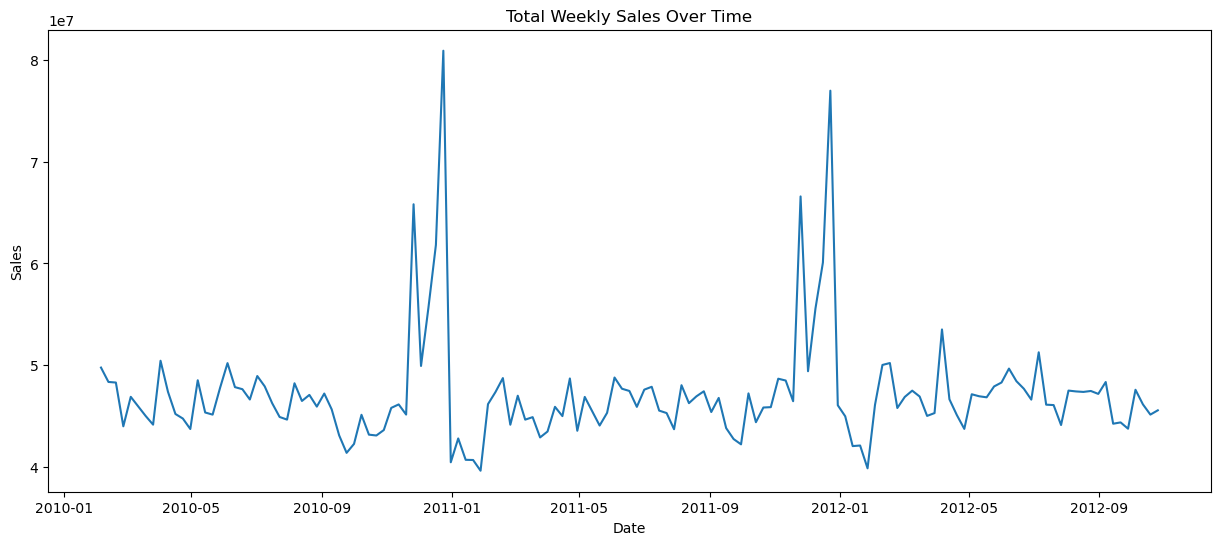

In [14]:
import matplotlib.pyplot as plt

sales_trend = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(15,6))
plt.plot(sales_trend)
plt.title('Total Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

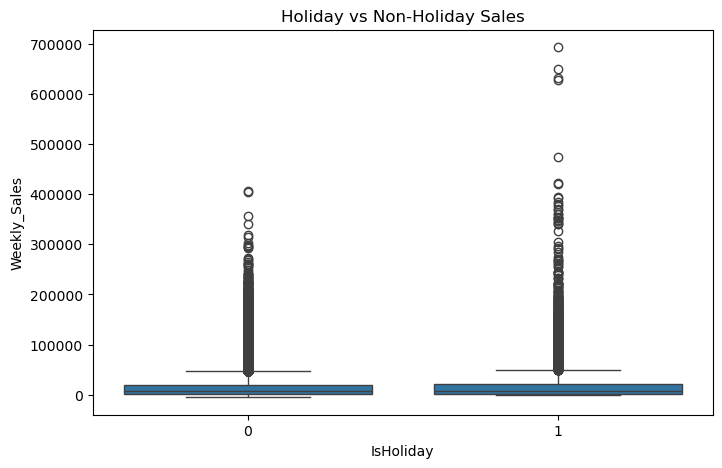

In [15]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df)
plt.title('Holiday vs Non-Holiday Sales')
plt.show()

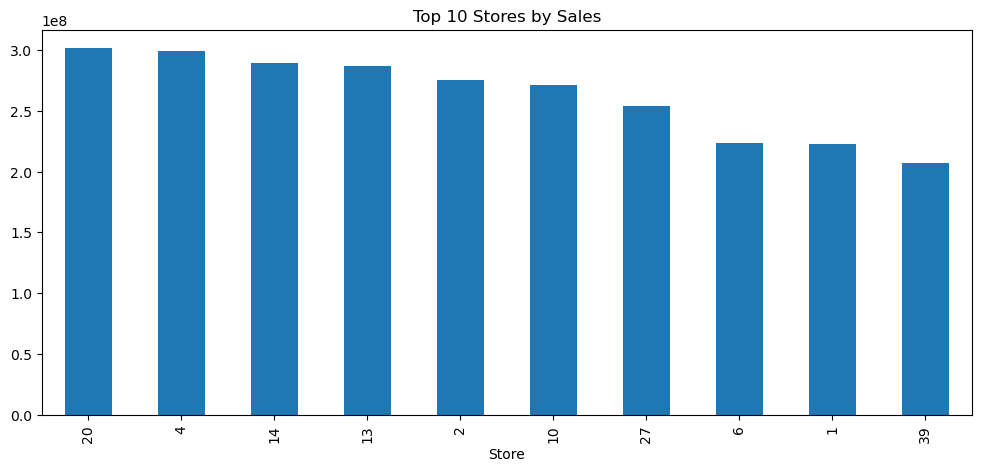

In [16]:
top_stores = (
    df.groupby('Store')['Weekly_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_stores.plot(kind='bar', figsize=(12,5))
plt.title('Top 10 Stores by Sales')
plt.show()

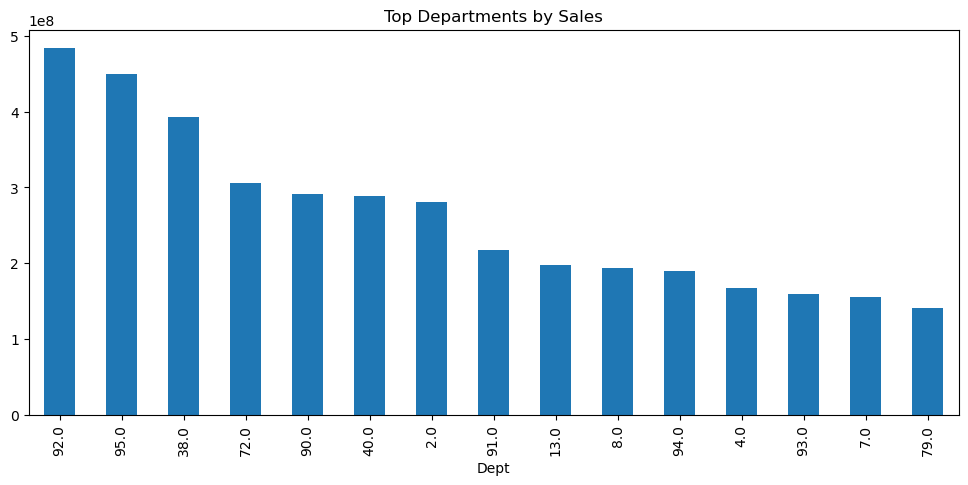

In [17]:
dept_sales = (
    df.groupby('Dept')['Weekly_Sales']
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

dept_sales.plot(kind='bar', figsize=(12,5))
plt.title('Top Departments by Sales')
plt.show()

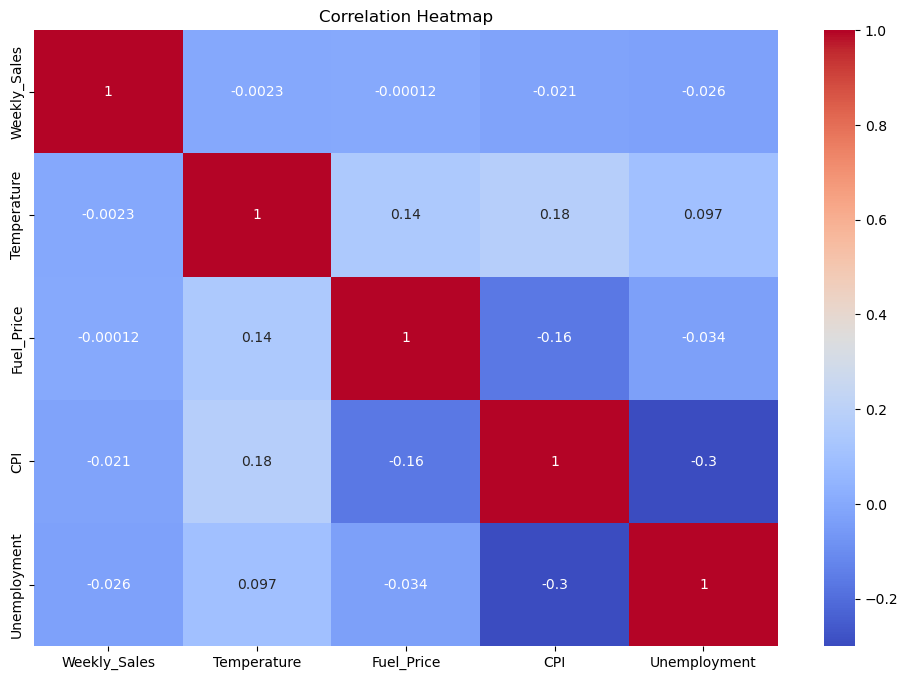

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[['Weekly_Sales',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

In [30]:
features = [
    'Store',
    'Dept',
    'IsHoliday',
    'Temperature',
    'Fuel_Price',
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5',
    'CPI',
    'Unemployment',
    'Size'
]

X = df[features]
y = df['Weekly_Sales']

In [31]:
forecast_df.shape

(143, 6)

In [32]:
forecast_df['Year'] = forecast_df['Date'].dt.year
forecast_df['Month'] = forecast_df['Date'].dt.month
forecast_df['Quarter'] = forecast_df['Date'].dt.quarter
forecast_df['Week'] = forecast_df['Date'].dt.isocalendar().week

In [33]:
forecast_df.head()

,Date,Weekly_Sales,Year,Month,Quarter,Week
0,2010-02-05,49750740.50,2010,2,1,5
1,2010-02-12,48336677.63,2010,2,1,6
2,2010-02-19,48276993.78,2010,2,1,7
3,2010-02-26,43968571.13,2010,2,1,8
4,2010-03-05,46871470.30,2010,3,1,9


In [34]:
X = forecast_df[['Year', 'Month', 'Quarter', 'Week']]
y = forecast_df['Weekly_Sales']

In [35]:
train_size = int(len(forecast_df) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [36]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [37]:
predictions = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    np.mean((y_test - predictions) ** 2)
)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 2598541.543512082
RMSE: 3052954.391016263
R²: -2.111484104432496


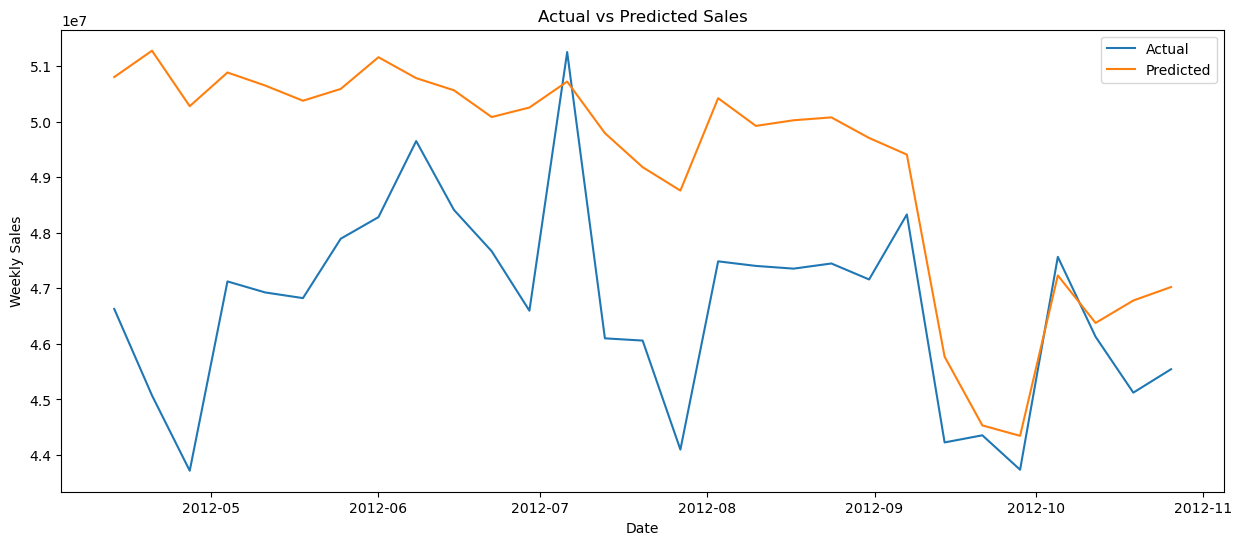

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    forecast_df['Date'][train_size:],
    y_test,
    label='Actual'
)

plt.plot(
    forecast_df['Date'][train_size:],
    predictions,
    label='Predicted'
)

plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()

plt.show()

In [29]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
3,Week,0.900511
1,Month,0.057151
0,Year,0.037448
2,Quarter,0.004891


In [39]:
pip install prophet


   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   --------- ------------------------------ 2.9/12.1 MB 14.7 MB/s eta 0:00:01
   ---------------- ----------------------- 5.0/12.1 MB 11.5 MB/s eta 0:00:01
   ------------------ --------------------- 5.5/12.1 MB 8.4 MB/s eta 0:00:01
   ------------------- -------------------- 5.8/12.1 MB 7.7 MB/s eta 0:00:01
   --------------------- ------------------ 6.6/12.1 MB 5.9 MB/s eta 0:00:01
   ------------------------- -------------- 7.6/12.1 MB 5.9 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 6.0 MB/s eta 0:00:01
   --------------------------------- ------ 10.2/12.1 MB 5.9 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  12.1/12.1 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 5.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ----

In [40]:
prophet_df = forecast_df[['Date','Weekly_Sales']]

prophet_df.columns = ['ds','y']

In [41]:
from prophet import Prophet

In [42]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

In [43]:
model.fit(prophet_df)

18:13:52 - cmdstanpy - INFO - Chain [1] start processing
18:13:54 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
future = model.make_future_dataframe(
    periods=26,
    freq='W'
)

In [45]:
future.tail()

,ds
164,2013-03-24
165,2013-03-31
166,2013-04-07
167,2013-04-14
168,2013-04-21


In [46]:
forecast = model.predict(future)

In [47]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
164,2013-03-24,4.643507e+07,4.201614e+07,5.115979e+07
165,2013-03-31,4.692911e+07,4.248993e+07,5.156949e+07
166,2013-04-07,4.794350e+07,4.378470e+07,5.223566e+07
167,2013-04-14,4.834270e+07,4.397538e+07,5.273663e+07
168,2013-04-21,4.748677e+07,4.312118e+07,5.204656e+07


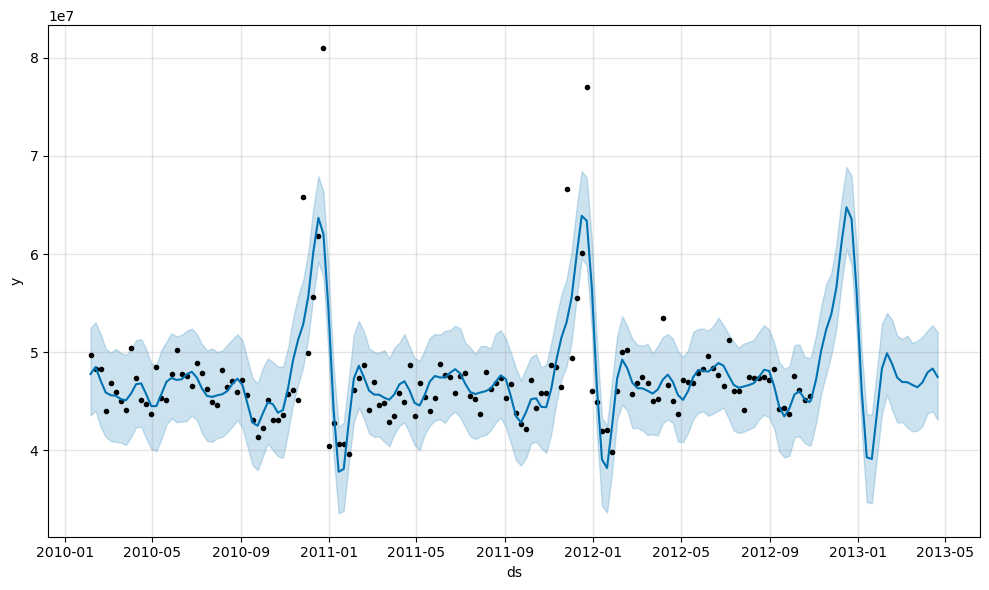

In [48]:
fig = model.plot(forecast)

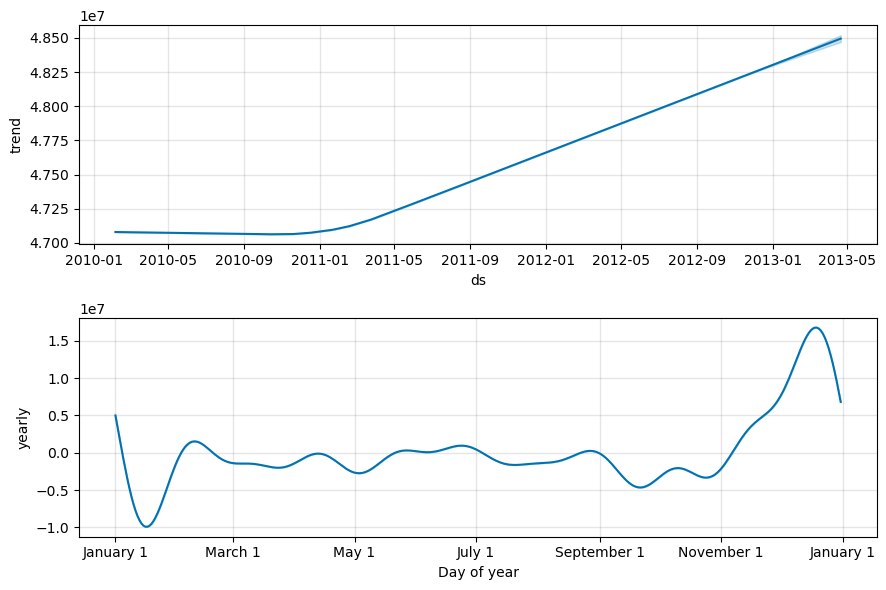

In [49]:
fig2 = model.plot_components(forecast)

In [50]:
forecast[['ds','yhat']].tail(26)

,ds,yhat
143,2012-10-28,4.515426e+07
144,2012-11-04,4.724269e+07
145,2012-11-11,5.016295e+07
146,2012-11-18,5.232036e+07
147,2012-11-25,5.386956e+07
148,2012-12-02,5.657599e+07
149,2012-12-09,6.106232e+07
150,2012-12-16,6.475826e+07
151,2012-12-23,6.358362e+07
152,2012-12-30,5.616720e+07


In [51]:
pip install streamlit plotly prophet pandas

Note: you may need to restart the kernel to use updated packages.


In [55]:
import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Sales Forecasting System",
    layout="wide"
)

st.title("📈 Sales Forecasting & Revenue Prediction System")

df = pd.read_csv("../data/walmart_cleaned.csv")

st.write(df.head())

2026-06-03 18:27:46.636 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 18:27:46.637 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 18:27:46.638 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 18:27:47.776 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-03 18:27:47.777 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [54]:
import os

os.listdir("../data")

['walmart_cleaned.csv']